# Trabalho Computacional 2: Equação do Calor bidimensional transiente/dependente do tempo
## PPG-Biometria
### Disciplina: Matemática Aplicada
### Professor: Fernando Luiz Pio dos Santos
### Aluno: Vitor Eduardo Girotto Barelli

## Objetivo

Resolver numericamente a equação do calor bidimensional transiente

## Solução numerica

In [1]:
# ============================================================
# Importações
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [2]:
# ============================================================
# Parâmetros físicos
# ============================================================

Lx = 1.0          # comprimento no eixo x
Ly = 1.0          # comprimento no eixo y
alpha = 1.0e-4    # difusividade térmica

In [3]:
# ============================================================
# Parâmetros numéricos
# ============================================================

Nx = 51           # número de pontos em x
Ny = 51           # número de pontos em y

dx = Lx / (Nx - 1)
dy = Ly / (Ny - 1)

dt = 0.1          # passo de tempo
t_final = 2000    # tempo final

Nt = int(t_final / dt)

In [4]:
# Critério de estabilidade para o método explícito 2D:
# alpha*dt*(1/dx^2 + 1/dy^2) <= 1/2

stability = alpha * dt * (1 / dx**2 + 1 / dy**2)

print(f"dx = {dx:.5f}")
print(f"dy = {dy:.5f}")
print(f"dt = {dt:.5f}")
print(f"Critério de estabilidade = {stability:.5f}")

if stability > 0.5:
    raise ValueError(
        "O método explícito está instável. Reduza dt ou aumente dx/dy."
    )

dx = 0.02000
dy = 0.02000
dt = 0.10000
Critério de estabilidade = 0.05000


In [5]:
# ============================================================
# Malha espacial
# ============================================================

x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)

X, Y = np.meshgrid(x, y)

In [6]:
# ============================================================
# Condição inicial
# ============================================================

T = np.zeros((Ny, Nx))

# Exemplo: ponto quente no centro do domínio
T0 = 100.0

cx = Lx / 2
cy = Ly / 2
sigma = 0.08

T[:, :] = T0 * np.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * sigma**2))

In [7]:
# ============================================================
# Condições de contorno de Dirichlet
# ============================================================

T_top = 0.0
T_bottom = 0.0
T_left = 0.0
T_right = 0.0

def apply_boundary_conditions(T):
    T[0, :] = T_bottom
    T[-1, :] = T_top
    T[:, 0] = T_left
    T[:, -1] = T_right
    return T

T = apply_boundary_conditions(T)

In [8]:
# ============================================================
# Coeficientes do esquema explícito
# ============================================================

rx = alpha * dt / dx**2
ry = alpha * dt / dy**2

print(f"rx = {rx:.5f}")
print(f"ry = {ry:.5f}")

rx = 0.02500
ry = 0.02500


In [9]:
# ============================================================
# Armazenamento para visualização
# ============================================================

snapshots = []
times = []

save_every = 200

In [10]:
# ============================================================
# Evolução temporal
# ============================================================

for n in range(Nt):
    T_old = T.copy()

    T[1:-1, 1:-1] = (
        T_old[1:-1, 1:-1]
        + rx * (T_old[1:-1, 2:] - 2*T_old[1:-1, 1:-1] + T_old[1:-1, :-2])
        + ry * (T_old[2:, 1:-1] - 2*T_old[1:-1, 1:-1] + T_old[:-2, 1:-1])
    )

    T = apply_boundary_conditions(T)

    if n % save_every == 0:
        snapshots.append(T.copy())
        times.append(n * dt)

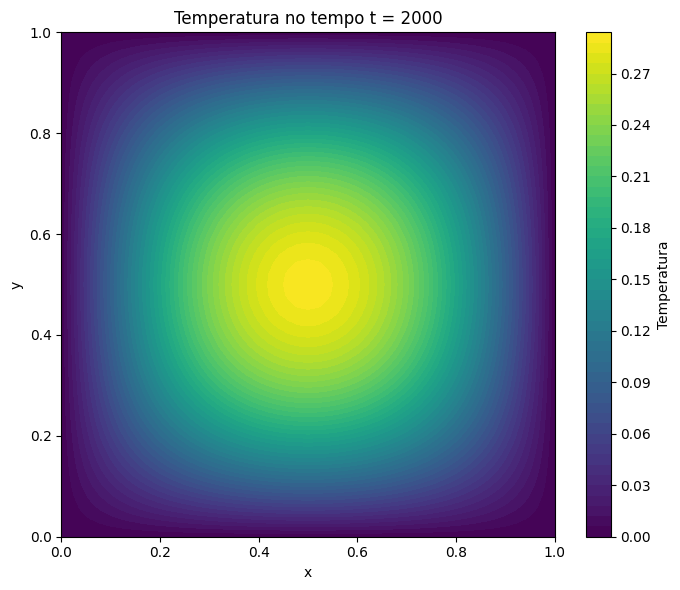

In [11]:
# ============================================================
# Resultado final
# ============================================================

plt.figure(figsize=(7, 6))
plt.contourf(X, Y, T, levels=50)
plt.colorbar(label="Temperatura")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Temperatura no tempo t = {t_final}")
plt.tight_layout()
plt.show()

## Vou colocar uma palhaçadinha: segue uma animação da Eq. do calor bidimensional transiente em um ambiente que o calor pode escapar e em um ambiente onde ele pode se espalhar, mas não escapar!

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib as mpl

# ============================================================
# Configuração para evitar limite pequeno de animação no Jupyter
# ============================================================
mpl.rcParams["animation.embed_limit"] = 100  # MB

# ============================================================
# Parâmetros físicos
# ============================================================
Lx = 1.0          # comprimento em x
Ly = 1.0          # comprimento em y
alpha = 1.0e-4    # difusividade térmica

# ============================================================
# Parâmetros numéricos
# ============================================================
Nx = 51           # número de pontos em x
Ny = 51           # número de pontos em y

dx = Lx / (Nx - 1)
dy = Ly / (Ny - 1)

dt = 0.1          # passo de tempo
t_final = 5000    # tempo final
Nt = int(t_final / dt)

save_every = 500  # salva um frame a cada 500 passos

# ============================================================
# Critério de estabilidade do método explícito 2D
# alpha*dt*(1/dx^2 + 1/dy^2) <= 1/2
# ============================================================
stability = alpha * dt * (1 / dx**2 + 1 / dy**2)

print(f"dx = {dx:.5f}")
print(f"dy = {dy:.5f}")
print(f"dt = {dt:.5f}")
print(f"Critério de estabilidade = {stability:.5f}")

if stability > 0.5:
    raise ValueError("Método explícito instável. Reduza dt ou aumente dx/dy.")

rx = alpha * dt / dx**2
ry = alpha * dt / dy**2

print(f"rx = {rx:.5f}")
print(f"ry = {ry:.5f}")

# ============================================================
# Malha espacial
# ============================================================
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y)

# ============================================================
# Condição inicial: fonte quente gaussiana no centro
# ============================================================
T0 = 100.0
cx = Lx / 2
cy = Ly / 2
sigma = 0.2

T_initial = T0 * np.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * sigma**2))

# ============================================================
# Condições de contorno
# ============================================================

def boundary_cold(T):
    """
    Bordas frias (Dirichlet): T = 0 nas fronteiras.
    O calor escapa da placa.
    """
    T[0, :] = 0.0      # borda inferior
    T[-1, :] = 0.0     # borda superior
    T[:, 0] = 0.0      # borda esquerda
    T[:, -1] = 0.0     # borda direita
    return T


def boundary_insulated(T):
    """
    Bordas isoladas (Neumann homogênea): dT/dn = 0.
    O calor não escapa da placa.
    """
    T[0, :] = T[1, :]      # borda inferior
    T[-1, :] = T[-2, :]    # borda superior
    T[:, 0] = T[:, 1]      # borda esquerda
    T[:, -1] = T[:, -2]    # borda direita
    return T

# ============================================================
# Solver da equação do calor 2D transiente
# ============================================================

def solve_heat_2d(T_initial, boundary_function):
    T = T_initial.copy()
    T = boundary_function(T)

    snapshots = []
    times = []

    # salva condição inicial
    snapshots.append(T.copy())
    times.append(0.0)

    for n in range(1, Nt + 1):
        T_old = T.copy()

        T[1:-1, 1:-1] = (
            T_old[1:-1, 1:-1]
            + rx * (T_old[1:-1, 2:] - 2 * T_old[1:-1, 1:-1] + T_old[1:-1, :-2])
            + ry * (T_old[2:, 1:-1] - 2 * T_old[1:-1, 1:-1] + T_old[:-2, 1:-1])
        )

        T = boundary_function(T)

        if n % save_every == 0:
            snapshots.append(T.copy())
            times.append(n * dt)

    return snapshots, times

# ============================================================
# Resolve os dois casos
# ============================================================
snapshots_cold, times = solve_heat_2d(T_initial, boundary_cold)
snapshots_insulated, _ = solve_heat_2d(T_initial, boundary_insulated)

# ============================================================
# Diagnóstico numérico
# ============================================================
print("\n=== Caso 1: Bordas frias ===")
print(f"Média inicial = {snapshots_cold[0].mean():.6f}")
print(f"Média final   = {snapshots_cold[-1].mean():.6f}")
print(f"Tmax final    = {snapshots_cold[-1].max():.6f}")

print("\n=== Caso 2: Bordas isoladas ===")
print(f"Média inicial = {snapshots_insulated[0].mean():.6f}")
print(f"Média final   = {snapshots_insulated[-1].mean():.6f}")
print(f"Tmax final    = {snapshots_insulated[-1].max():.6f}")
print(f"Tmin final    = {snapshots_insulated[-1].min():.6f}")

# ============================================================
# Animação comparativa
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax1, ax2 = axes

# Escala do caso frio: fixa de 0 a 100
img1 = ax1.imshow(
    snapshots_cold[0],
    extent=[0, Lx, 0, Ly],
    origin="lower",
    vmin=0,
    vmax=100,
    interpolation="bilinear",
    cmap="viridis"
)

# Escala do caso isolado:
# usamos uma escala menor para visualizar o espalhamento no final
img2 = ax2.imshow(
    snapshots_insulated[0],
    extent=[0, Lx, 0, Ly],
    origin="lower",
    vmin=0,
    vmax=100,
    interpolation="bilinear",
    cmap="viridis"
)

cbar1 = fig.colorbar(img1, ax=ax1)
cbar1.set_label("Temperatura")

cbar2 = fig.colorbar(img2, ax=ax2)
cbar2.set_label("Temperatura")

ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_title("Bordas frias: calor escapa")

ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_title("Bordas isoladas: calor se espalha")

title = fig.suptitle(f"t = {times[0]:.2f}")

def update(frame):
    data_cold = snapshots_cold[frame]
    data_insulated = snapshots_insulated[frame]

    img1.set_data(data_cold)
    img2.set_data(data_insulated)

    title.set_text(
        f"t = {times[frame]:.2f} | "
        f"Bordas frias Tmax = {data_cold.max():.3f} | "
        f"Bordas isoladas Tmax = {data_insulated.max():.3f}"
    )

    return [img1, img2, title]

anim = FuncAnimation(
    fig,
    update,
    frames=len(times),
    interval=180,
    blit=False
)

plt.close(fig)

HTML(anim.to_jshtml())

dx = 0.02000
dy = 0.02000
dt = 0.10000
Critério de estabilidade = 0.05000
rx = 0.02500
ry = 0.02500

=== Caso 1: Bordas frias ===
Média inicial = 23.473473
Média final   = 0.001375
Tmax final    = 0.003532

=== Caso 2: Bordas isoladas ===
Média inicial = 23.687268
Média final   = 25.428781
Tmax final    = 25.428781
Tmin final    = 25.428781
